In [4]:
from planning.planner import connect_poses_with_curvature, pose_to_node, node_to_pose, plan_from_path, a_star, create_graph, add_edges
import networkx as nx
import matplotlib.pyplot as plt
from aido_schemas import Context, FriendlyPose
from dt_protocols import PlanningSetup, Rectangle, Circle, PlacedPrimitive, Appearance
import math
import numpy as np

ps = PlanningSetup(
    environment=[
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=0.1, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=4.9, ymin=0.0, xmax=5.0, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=4.9, xmax=5.0, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=5.0, ymax=0.1),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.539619150260162, y=2.764151352098707, theta_deg=200.25092590378074),
            primitive=Circle(radius=0.4955915626161882),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.028568920007228, y=2.285092439438581, theta_deg=178.09485615456518),
            primitive=Circle(radius=0.7575022270458687),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.6254208399349936, y=0.21987096862042532, theta_deg=320.4926048628041),
            primitive=Circle(radius=0.6675524439185758),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.125671199410717, y=4.170206386803661, theta_deg=175.58822051345493),
            primitive=Circle(radius=0.5670801581108957),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.51392445095758, y=3.9871575410872353, theta_deg=206.0268476129309),
            primitive=Circle(radius=0.45107485977504896),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.6731420817120276, y=3.9482933242598985, theta_deg=42.59271886758431),
            primitive=Circle(radius=0.6283525898487949),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.3740911457165907, y=3.1708367703589997, theta_deg=349.73363772371755),
            primitive=Circle(radius=0.34614476347426265),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=2.9854067191328992, y=2.204884814489365, theta_deg=224.0830942194504),
            primitive=Rectangle(
                xmin=-0.3451722951775122, ymin=-0.22614183237669566,
                xmax=0.3451722951775122, ymax=0.22614183237669566
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.2676078081257216, y=2.5452693717253356, theta_deg=326.80660552685725),
            primitive=Rectangle(
                xmin=-0.3024006603443898, ymin=-0.32153226185970135,
                xmax=0.3024006603443898, ymax=0.32153226185970135
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.2234594147202889, y=2.8629082010227744, theta_deg=331.0065395116919),
            primitive=Rectangle(
                xmin=-0.2503264595125117, ymin=-0.3295076552525854,
                xmax=0.2503264595125117, ymax=0.3295076552525854
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.35700000513042396, y=0.4306467698119637, theta_deg=49.52091657795261),
            primitive=Rectangle(
                xmin=-0.25126489066548285, ymin=-0.23991484191677537,
                xmax=0.25126489066548285, ymax=0.23991484191677537
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.8050801066863106, y=2.090759274161887, theta_deg=155.73643133572406),
            primitive=Rectangle(
                xmin=-0.31161477269728577, ymin=-0.3700610259863343,
                xmax=0.31161477269728577, ymax=0.3700610259863343
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.786671021694601, y=0.12334100795562519, theta_deg=127.87379050822763),
            primitive=Rectangle(
                xmin=-0.213766825486308, ymin=-0.23112790550116707,
                xmax=0.213766825486308, ymax=0.23112790550116707
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=2.1969914039975658, y=0.57650745756812, theta_deg=143.55133291933856),
            primitive=Rectangle(
                xmin=-0.35460471946640426, ymin=-0.22756394716538508,
                xmax=0.35460471946640426, ymax=0.22756394716538508
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
    ],
    body=[
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=-0.13, ymin=-0.045, xmax=0.07, ymax=0.045),
            appearance=Appearance(fillcolor="blue", rel_zorder=1),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=-0.03, ymin=-0.065, xmax=0.03, ymax=0.065),
            appearance=Appearance(fillcolor="black", rel_zorder=-1),
        ),
    ],
    bounds=Rectangle(xmin=0.0, ymin=0.0, xmax=5.0, ymax=5.0),
    max_linear_velocity_m_s=0.4,
    min_linear_velocity_m_s=-0.3,
    max_angular_velocity_deg_s=30.0,
    max_curvature=float("inf"),
    tolerance_xy_m=0.05,
    tolerance_theta_deg=20.0,
)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_plan(start_pose, plan):
    """
    Simulate the trajectory given a start pose (FriendlyPose) and a plan (list of PlanStep).
    Returns arrays of x, y, theta.
    """
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg
    xs, ys, thetas = [x], [y], [theta_deg]
    for step in plan:
        duration = step.duration
        v = step.velocity_x_m_s
        w_deg = step.angular_velocity_deg_s
        w = np.deg2rad(w_deg)
        theta = np.deg2rad(theta_deg)
        dt = 0.001
        n = max(1, int(duration / dt))
        for _ in range(n):
            if abs(w) < 1e-6:
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
            else:
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
                theta += w * dt
            xs.append(x)
            ys.append(y)
            thetas.append(np.rad2deg(theta))
        theta_deg = np.rad2deg(theta)
    return np.array(xs), np.array(ys), np.array(thetas)

def plot_trajectory_from_path(plan, path, planning_setup=None):
    """
    Plots the continuous trajectory defined by the plans on the edges of the path.
    The line is blue if the vehicle moves forward, green if it moves backward.
    If planning_setup is provided, also plots the environment.
    """

    def draw_primitive(ax, placed_primitive):
        pose = placed_primitive.pose
        primitive = placed_primitive.primitive
        appearance = getattr(placed_primitive, "appearance", None)
        color = getattr(appearance, "fillcolor", "gray") if appearance else "gray"
        if isinstance(primitive, Rectangle):
            # Rectangle is defined in local frame, so we need to transform corners
            corners = np.array([
                [primitive.xmin, primitive.ymin],
                [primitive.xmax, primitive.ymin],
                [primitive.xmax, primitive.ymax],
                [primitive.xmin, primitive.ymax],
                [primitive.xmin, primitive.ymin],
            ])
            # Rotation
            theta = np.deg2rad(pose.theta_deg)
            R = np.array([[np.cos(theta), -np.sin(theta)],
                          [np.sin(theta),  np.cos(theta)]])
            rotated = (R @ corners.T).T
            # Translation
            translated = rotated + np.array([pose.x, pose.y])
            ax.plot(translated[:,0], translated[:,1], color=color, linewidth=0)
            ax.fill(translated[:,0], translated[:,1], color=color, alpha=0.8)
        elif isinstance(primitive, Circle):
            circle = plt.Circle((pose.x, pose.y), primitive.radius, color=color, alpha=0.8, linewidth=0)
            ax.add_patch(circle)

    start_node = path[0]
    start_pose = node_to_pose(start_node)
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg

    fig, ax = plt.subplots(figsize=(6,6))
    xs_all, ys_all = [x], [y]  # For start/goal markers

    # Draw environment if provided
    if planning_setup is not None:
        for placed_primitive in getattr(planning_setup, "environment", []):
            draw_primitive(ax, placed_primitive)

    for step in plan:
        # Simulate this step only
        temp_pose = type(start_pose)(x, y, theta_deg)
        xs, ys, thetas = simulate_plan(temp_pose, [step])
        # Only plot the segment (not the repeated start)
        color = 'blue' if step.velocity_x_m_s > 0 else 'green'
        ax.plot(xs, ys, color=color)
        # Update for next step
        x, y, theta_deg = xs[-1], ys[-1], thetas[-1]
        xs_all.extend(xs[1:])  # skip the first point to avoid duplicates
        ys_all.extend(ys[1:])

    ax.scatter([xs_all[0], xs_all[-1]], [ys_all[0], ys_all[-1]], c='red', label="Start/Goal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title("Planned Trajectory (from edge plans)")
    ax.axis('equal')
    ax.grid(True)
    ax.legend()
    plt.show()

/code/planning/packages/planning/planner.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 6217 nodes visited


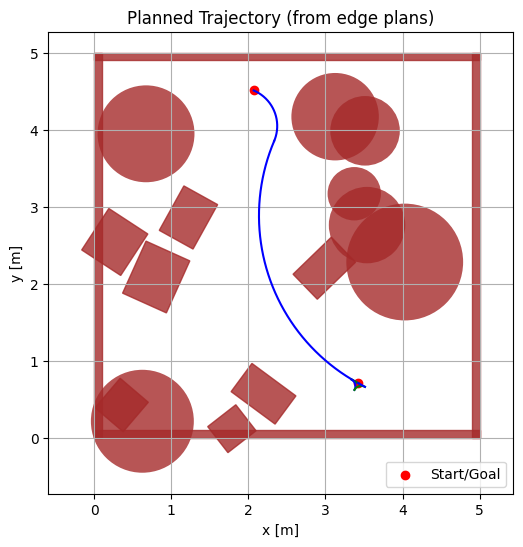

[(207, 451, 337), (233, 385, 247), (342, 71, 331.28722809483247), (333, 76, 331), (337, 62, 241), (351, 66, 151), (342, 71, 151)]
[PlanStep(duration=3.0, velocity_x_m_s=0.2617993877991495, angular_velocity_deg_s=-30.0), PlanStep(duration=9.108948550098393, velocity_x_m_s=0.4, angular_velocity_deg_s=9.25323352429321), PlanStep(duration=0.33333333333333337, velocity_x_m_s=-0.3, angular_velocity_deg_s=0.0), PlanStep(duration=3.0, velocity_x_m_s=0.05235987755982991, angular_velocity_deg_s=-30.0), PlanStep(duration=3.0, velocity_x_m_s=-0.05235987755982991, angular_velocity_deg_s=-30.0), PlanStep(duration=0.25, velocity_x_m_s=0.4, angular_velocity_deg_s=0.0)]
18.692281883431725


In [6]:
# A star
start = FriendlyPose(2.0667262838450213, 4.514478476178308, 337.1563223638467)
goal = FriendlyPose(3.4199032893600485, 0.7103381954156884, 142.31580213952952)

plan, path = a_star(ps, start, goal)

if plan is not None:
    plot_trajectory_from_path(plan, path, ps)

print(path)
print(plan)
print(sum([step.duration for step in plan]))